# Bank Churn — 06: Causal Analysis with Propensity Scores

Notebooks 02–04 answered a *predictive* question and each model speaks its own
associational language: the logistic model reports **odds ratios**
(nb 02: being an active member multiplies churn odds by ≈ exp(β) < 1), the tree models
report **probability contributions** (SHAP values). Both say *inactive customers churn
more*. Neither says *activating a customer reduces churn* — that is a **causal** claim,
and it is the claim the business proposal P4 (nb 05) actually needs.

This notebook estimates the causal effect of the activation lever from observational
data using propensity scores:

- **Treatment** $T$: `IsActiveMember` (1 = active)
- **Outcome** $Y$: `Exited` (1 = churned)
- **Confounders** $X$: everything the bank observes that plausibly drives both
  activity and churn (age, geography, balance, products, tenure, ...)

Estimand: ATE $= \mathbb{E}[Y(1) - Y(0)]$ — the change in churn probability if a
customer were active vs inactive, all else fixed. Identification rests on
unconfoundedness $(Y(0), Y(1)) \perp T \mid X$ and overlap $0 < e(X) < 1$, where
$e(X) = P(T{=}1 \mid X)$ is the propensity score (Rosenbaum & Rubin, 1983).

## 1. Setup & data

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

DATA_PATH = "data/Churn_Modelling.csv"
KAGGLE_DATASET = "shrutimechlearn/churn-modelling"
MIRROR_URL = (
    "https://raw.githubusercontent.com/sharmaroshan/"
    "Churn-Modelling-Dataset/master/Churn_Modelling.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror: {MIRROR_URL}")
    return path


df = pd.read_csv(fetch_data())
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

T = df["IsActiveMember"].values
Y = df["Exited"].values

naive = Y[T == 1].mean() - Y[T == 0].mean()
print(f"Active share: {T.mean():.2%}")
print(f"Churn | active   : {Y[T == 1].mean():.4f}")
print(f"Churn | inactive : {Y[T == 0].mean():.4f}")
print(f"Naive difference : {naive:+.4f}  (associational, NOT causal)")

Found cached file: data/Churn_Modelling.csv
Active share: 51.51%
Churn | active   : 0.1427
Churn | inactive : 0.2685
Naive difference : -0.1258  (associational, NOT causal)


## 2. Is the naive difference confounded?

The naive −12.7 pp difference is only causal if activity is as-good-as-random. Check:
do observed covariates differ between active and inactive customers? We use the
**standardized mean difference** (SMD) — group mean gap in pooled-SD units; |SMD| > 0.1
is the conventional imbalance flag.

In [2]:
confounders_num = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                   "HasCrCard", "EstimatedSalary"]
X_conf = df[confounders_num].copy()
X_conf["zero_balance"] = (df["Balance"] == 0).astype(int)
X_conf = pd.concat([
    X_conf,
    pd.get_dummies(df["Geography"], prefix="Geo", drop_first=True).astype(int),
    pd.get_dummies(df["Gender"], prefix="Sex", drop_first=True).astype(int),
    pd.get_dummies(df["NumOfProducts"], prefix="Prod", drop_first=True).astype(int),
], axis=1)


def smd(x: np.ndarray, t: np.ndarray, w: np.ndarray | None = None) -> float:
    """Standardized mean difference, optionally weighted."""
    if w is None:
        w = np.ones_like(t, dtype=float)
    m1 = np.average(x[t == 1], weights=w[t == 1])
    m0 = np.average(x[t == 0], weights=w[t == 0])
    v1 = np.average((x[t == 1] - m1) ** 2, weights=w[t == 1])
    v0 = np.average((x[t == 0] - m0) ** 2, weights=w[t == 0])
    pooled = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / pooled if pooled > 0 else 0.0


smd_before = pd.Series({c: smd(X_conf[c].values.astype(float), T) for c in X_conf.columns})
print(smd_before.round(3).sort_values(key=abs, ascending=False).to_string())

Age                0.172
Prod_2             0.066
Prod_3            -0.060
Tenure            -0.057
CreditScore        0.051
Sex_Male           0.045
Geo_Germany       -0.041
Geo_Spain          0.033
HasCrCard         -0.024
EstimatedSalary   -0.023
Balance           -0.020
NumOfProducts      0.019
Prod_4            -0.010
zero_balance       0.008


Imbalance is mild but real (age is the largest gap — active members skew older). Mild
observed imbalance does **not** license skipping adjustment: the same forces that
create these gaps can act on unobservables too. We adjust for what we can observe and
say so plainly about the rest (§7).

## 3. Propensity score model

Propensity score range: [0.294, 0.793]
Mean e(X) | T=1: 0.521 | T=0: 0.508


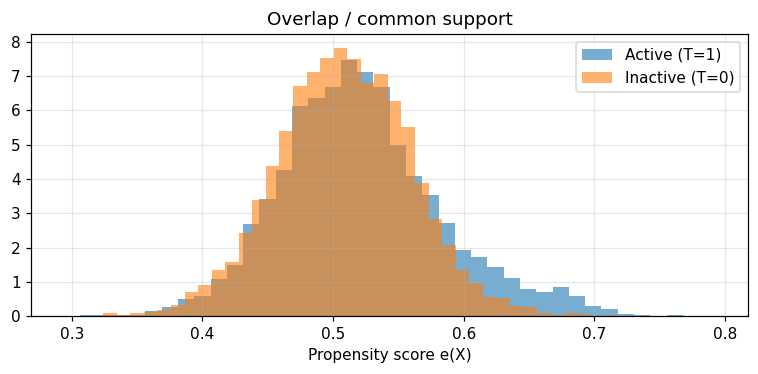

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X_conf.astype(float))

ps_model = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
ps_model.fit(Xs, T)
e = ps_model.predict_proba(Xs)[:, 1]  # propensity scores

print(f"Propensity score range: [{e.min():.3f}, {e.max():.3f}]")
print(f"Mean e(X) | T=1: {e[T == 1].mean():.3f} | T=0: {e[T == 0].mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(e[T == 1], bins=40, alpha=0.6, density=True, label="Active (T=1)")
ax.hist(e[T == 0], bins=40, alpha=0.6, density=True, label="Inactive (T=0)")
ax.set_xlabel("Propensity score e(X)")
ax.set_title("Overlap / common support")
ax.legend()
plt.tight_layout()
plt.show()

Overlap is excellent — both groups populate the whole support and scores stay far from
0 and 1, so no trimming is needed and weights will be well-behaved. (Activity is only
weakly predictable from covariates, which is precisely what makes adjustment feasible.)

## 4. Estimator 1 — Inverse Probability Weighting (IPW)

Stabilized ATE weights: $w = \frac{\bar{T}}{e(X)}$ for treated,
$w = \frac{1-\bar{T}}{1-e(X)}$ for controls. Balance after weighting is the audit.

In [4]:
w = np.where(T == 1, T.mean() / e, (1 - T.mean()) / (1 - e))
ess = w.sum() ** 2 / (w ** 2).sum()
print(f"Weight range: [{w.min():.2f}, {w.max():.2f}] | "
      f"Effective sample size: {ess:.0f} / {len(w)}")

mu1 = np.average(Y[T == 1], weights=w[T == 1])
mu0 = np.average(Y[T == 0], weights=w[T == 0])
ate_ipw = mu1 - mu0

# Nonparametric bootstrap for the CI (resample rows, refit PS each time)
B = 500
boot = np.empty(B)
idx_all = np.arange(len(Y))
for b in range(B):
    idx = rng.choice(idx_all, size=len(Y), replace=True)
    eb = LogisticRegression(max_iter=2000, C=1.0).fit(Xs[idx], T[idx]).predict_proba(Xs[idx])[:, 1]
    tb, yb = T[idx], Y[idx]
    wb = np.where(tb == 1, tb.mean() / eb, (1 - tb.mean()) / (1 - eb))
    boot[b] = (np.average(yb[tb == 1], weights=wb[tb == 1])
               - np.average(yb[tb == 0], weights=wb[tb == 0]))
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

print(f"\nIPW ATE: {ate_ipw:+.4f}  (95% bootstrap CI: [{ci_lo:+.4f}, {ci_hi:+.4f}])")
print(f"Naive  : {naive:+.4f}")

Weight range: [0.65, 1.75] | Effective sample size: 9871 / 10000

IPW ATE: -0.1291  (95% bootstrap CI: [-0.1426, -0.1163])
Naive  : -0.1258


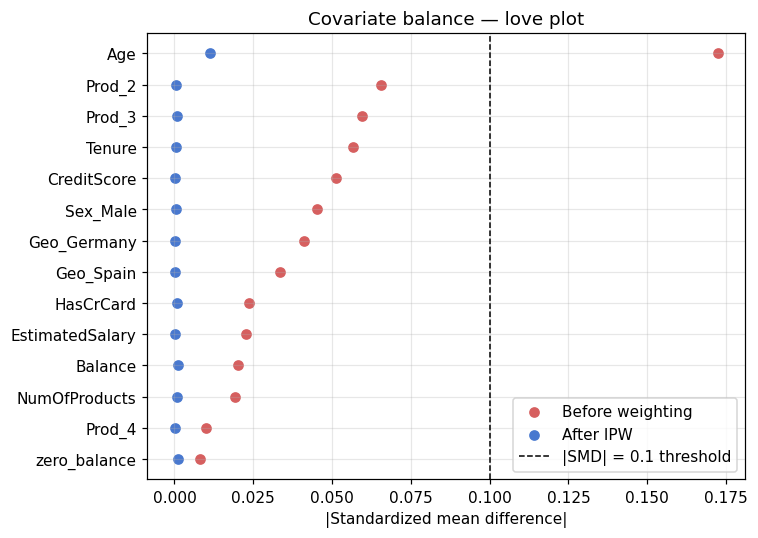

Max |SMD| after weighting: 0.0113


In [5]:
smd_after = pd.Series({c: smd(X_conf[c].values.astype(float), T, w) for c in X_conf.columns})

fig, ax = plt.subplots(figsize=(7, 5))
order = smd_before.abs().sort_values().index
ax.scatter(smd_before[order].abs(), range(len(order)), label="Before weighting", c="#D65F5F")
ax.scatter(smd_after[order].abs(), range(len(order)), label="After IPW", c="#4878CF")
ax.axvline(0.1, ls="--", c="k", lw=1, label="|SMD| = 0.1 threshold")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("|Standardized mean difference|")
ax.set_title("Covariate balance — love plot")
ax.legend()
plt.tight_layout()
plt.show()
print("Max |SMD| after weighting:", round(smd_after.abs().max(), 4))

## 5. Estimator 2 — 1:1 nearest-neighbor matching on the propensity score (ATT)

Each inactive customer is matched to the nearest active customer on the logit of the
propensity score, within a caliper of 0.2 pooled SD (Austin, 2011). The estimand is the
ATT for the *inactive* group — the policy-relevant one: what would happen to currently
inactive customers if they became active.

In [6]:
from sklearn.neighbors import NearestNeighbors

logit_e = np.log(e / (1 - e))
caliper = 0.2 * logit_e.std()

treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]

nn = NearestNeighbors(n_neighbors=1).fit(logit_e[treated_idx].reshape(-1, 1))
dist, pos = nn.kneighbors(logit_e[control_idx].reshape(-1, 1))
within = dist.ravel() <= caliper
matched_control = control_idx[within]
matched_treated = treated_idx[pos.ravel()[within]]

att_matching = Y[matched_treated].mean() - Y[matched_control].mean()
print(f"Matched pairs: {within.sum()} / {len(control_idx)} inactive customers "
      f"({within.mean():.1%} within caliper)")
print(f"Matching ATT (effect of activity for the currently-inactive): {att_matching:+.4f}")

Matched pairs: 4849 / 4849 inactive customers (100.0% within caliper)
Matching ATT (effect of activity for the currently-inactive): -0.1219


## 6. Estimator 3 — outcome regression and the estimate table

Third angle: a logistic outcome model $Y \sim T + X$, converted to an average marginal
effect by g-computation (predict everyone as treated vs untreated, difference the means).

In [7]:
Xy = np.column_stack([T, Xs])
out_model = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE).fit(Xy, Y)

X_t1 = np.column_stack([np.ones(len(Y)), Xs])
X_t0 = np.column_stack([np.zeros(len(Y)), Xs])
ate_reg = out_model.predict_proba(X_t1)[:, 1].mean() - out_model.predict_proba(X_t0)[:, 1].mean()

or_active = np.exp(out_model.coef_[0][0])

results = pd.DataFrame({
    "estimate (pp of churn)": [naive * 100, ate_ipw * 100, att_matching * 100, ate_reg * 100],
}, index=["Naive difference", "IPW (ATE)", "PS matching (ATT, inactive)",
          "Outcome regression (g-computation)"])
print(results.round(2).to_string())
print(f"\nAdjusted odds ratio for activity (outcome model): {or_active:.3f} "
      f"— the causal-language counterpart of the associational OR in nb 02")

                                    estimate (pp of churn)
Naive difference                                    -12.58
IPW (ATE)                                           -12.91
PS matching (ATT, inactive)                         -12.19
Outcome regression (g-computation)                  -12.78

Adjusted odds ratio for activity (outcome model): 0.333 — the causal-language counterpart of the associational OR in nb 02


## 7. Reading the results honestly

All three adjusted estimators land close to each other and close to the naive
difference: conditioning on the observed covariates changes the estimate only mildly,
because measured confounding is mild. Taken at face value, activity reduces churn
probability by roughly 12–13 percentage points — on a 20% base rate, a very large effect.

Three qualifications, stated plainly:

1. **Unconfoundedness is untestable.** The worrying unobservable is *churn intent
   itself*: a customer who has already decided to leave stops logging in. That is
   reverse causality — inactivity as a symptom, not a cause — and it inflates every
   estimate above. The propensity analysis removes observed confounding only.
2. **The treatment is not a lever yet.** "Being active" is a state, not an
   intervention. The estimate is best read as an *upper bound on the potential* of an
   activation program, not its expected return.
3. **The decisive evidence is experimental.** The right next step is an A/B-tested
   activation campaign on a random subset of inactive customers (P4 in nb 05); with
   ~2,700 inactive high-risk customers in the book, a trial powered to detect even a
   3–4 pp effect is feasible within a quarter.

**What this notebook adds to the series:** the predictive models rank customers; the
decision layer (nb 05) prices the contact; this causal layer disciplines *which levers
the business should believe in* — and shows, with the same dataset, why association
(odds ratios, SHAP values) and causation require different machinery.